In [6]:
import os
import time
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
from ultralytics import YOLO
from rfdetr import RFDETRMedium
import supervision as sv

In [7]:
device = 'cuda' if torch.cuda.is_available() \
    else 'mps' if torch.backends.mps.is_available() \
    else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif device == 'mps':
    print(f"GPU: Apple Silicon")

Using device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB


In [8]:
DATA_YAML   = '/mnt/d/Abhishek/Studio2Project/dataset/optimizedDataset/converted_for_yolo/data.yaml'
DATASET_DIR = '/mnt/d/Abhishek/Studio2Project/dataset/optimizedDataset/converted_for_rf_detr/'
OUTPUT_DIR  = '/mnt/d/Abhishek/Studio2Project/output/'
EPOCHS      = 50
BATCH_SIZE  = 16
IMG_SIZE    = 640
CONF_THRESH = 0.5
TEST_IMAGES = '/mnt/d/Abhishek/Studio2Project/dataset/optimizedDataset/converted_for_yolo/test/images/'

In [9]:
for split in ['train', 'valid', 'test']:
    imgs   = list(Path(DATA_YAML).parent.joinpath(split, 'images').glob('*.*'))
    labels = list(Path(DATA_YAML).parent.joinpath(split, 'labels').glob('*.txt'))
    print(f"{split:6s} → {len(imgs):5d} images | {len(labels):5d} labels")

train  →  5600 images |  5600 labels
valid  →   700 images |   700 labels
test   →   700 images |   700 labels


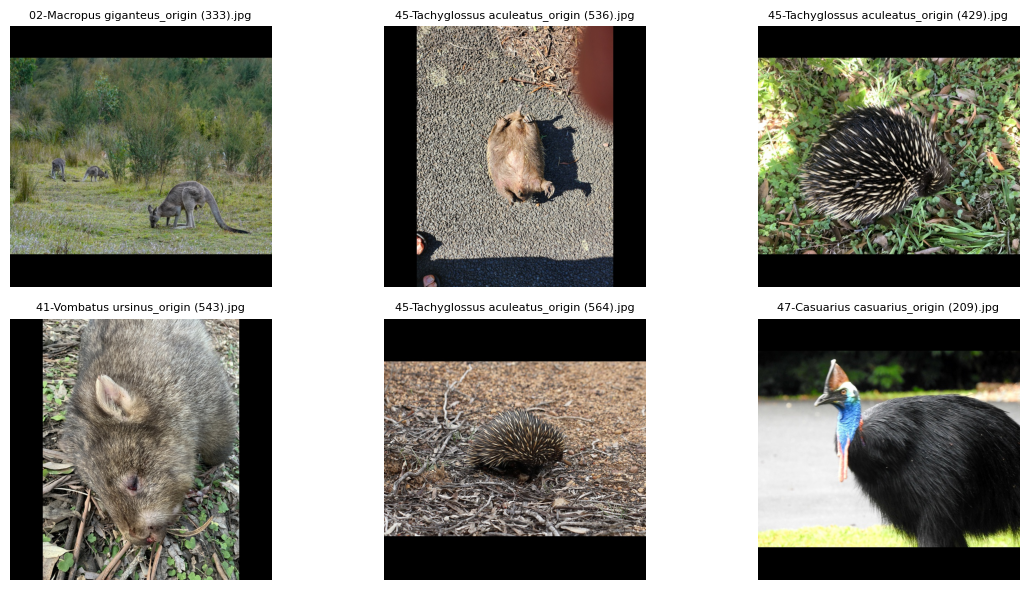

In [10]:
train_imgs = list(Path(DATA_YAML).parent.joinpath('train', 'images').glob('*.*'))
sample     = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, img_path in zip(axes.flat, sample):
    ax.imshow(Image.open(img_path))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
yolo_model = YOLO('yolo11m.pt')
print(yolo_model.info())

YOLO11m summary: 231 layers, 20,114,688 parameters, 0 gradients, 68.5 GFLOPs
(231, 20114688, 0, 68.52838399999999)


In [10]:
import os
os.makedirs('yolo_runs', exist_ok=True)

yolo_train_start = time.time()

yolo_results = yolo_model.train(
    data        = DATA_YAML,
    epochs      = EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    device      = device,
    name        = 'yolo_checkpoints',
    project     = 'yolo_runs',
    patience    = 10,
    optimizer   = 'AdamW',
    lr0         = 0.001,
    plots       = False,
    save_period = 5
)

yolo_train_time = time.time() - yolo_train_start
print(f"Training done in {yolo_train_time/60:.1f} mins")
print(f"Best weights: yolo_runs/yolo_checkpoints/weights/best.pt")

Ultralytics 8.4.37 🚀 Python-3.12.3 torch-2.12.0.dev20260407+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/d/Abhishek/Studio2Project/dataset/optimizedDataset/converted_for_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_checkpoints, nbs=6

In [12]:
rfdetr_model = RFDETRMedium()
history = []
def log_epoch(data):
    history.append(data)
rfdetr_model.callbacks["on_fit_epoch_end"].append(log_epoch)

[2026-04-13 00:58:48] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


[2026-04-13 00:58:48] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-13 00:58:48] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-13 00:58:56] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


In [11]:
rfdetr_train_start = time.time()

rfdetr_model.train(
    dataset_dir        = DATASET_DIR,
    epochs             = EPOCHS,
    batch_size         = BATCH_SIZE,
    grad_accum_steps   = 1,
    lr                 = 1e-4,
    output_dir         = '/mnt/d/Abhishek/Studio2Project/rfdetr_runs/',
    checkpoint_interval= 5,
    device             = device
)

rfdetr_train_time = time.time() - rfdetr_train_start
print(f"Training done in {rfdetr_train_time/60:.1f} mins")
print(f"Best checkpoint: /mnt/d/Abhishek/Studio2Project/rfdetr_runs/checkpoint_best_total.pth")

[2026-04-11 01:27:45] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-11 01:27:45] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-11 01:27:53] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


[2026-04-11 01:28:04] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 10. The detection head will be re-initialized to 10 classes.
[2026-04-11 01:28:04] [WARNING] rf-detr - TensorBoard logging disabled: Neither `tensorboard` nor `tensorboardX` is available. Try `pip install`ing either.
Requirement 'tensorboardX' not met. HINT: Try running `pip install -U 'tensorboardX'`
Requirement 'tensorboard' not met. HINT: Try running `pip install -U 'tensorboard'`. Install with: pip install tensorboard
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[2026-04-11 01:28:04] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 576
[2026-04-11 01:28:04] [INFO] rf-detr - Using multi-scale training with square resize and scales: [736]
[2026-04-11 01:28:04] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-04-11 01:28:04] [INFO] rf-detr - Built 1 Albumentations transforms from config


/mnt/d/Abhishek/Studio2Project/studio2/lib/python3.12/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory /mnt/d/Abhishek/Studio2Project/rfdetr_runs/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!


...

                           Val — Per-class Metrics                            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class                    ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ Dromaius novaehollandiae │   0.8731 │ 0.9160 │ 0.9178 │    0.9437 │ 0.8933 │
│ Macropus giganteus       │   0.8971 │ 0.9319 │ 0.9128 │    0.8831 │ 0.9444 │
│ Phascolarctos cinereus   │   0.7704 │ 0.7988 │ 0.8734 │    0.9200 │ 0.8313 │
│ Wallabia bicolor         │   0.7909 │ 0.8803 │ 0.8824 │    1.0000 │ 0.7895 │
│ Vulpes vulpes            │   0.8011 │ 0.8416 │ 0.9459 │    0.9859 │ 0.9091 │
│ Ornithorhynchus anatinus │   0.5996 │ 0.6729 │ 0.8354 │    0.9041 │ 0.7765 │
│ Vombatus ursinus         │   0.9081 │ 0.9216 │ 0.9444 │    0.9714 │ 0.9189 │
│ Dasyurus maculatus       │   0.6729 │ 0.7208 │ 0.8056 │    0.8657 │ 0.7532 │
│ Tachyglossus aculeatus   │   0.6906 │ 0.7163 │ 0.8642 │    1.0000 │ 0.7609 │
│ Casuarius casuarius      │   0.6883 │ 0.7373 │ 0.8539 │    1.0000 │ 0.7451 │
└──────────────────────────┴──────────┴────────┴────────┴───────────┴────────┘

Val — Overall Metrics                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.7549 │ 0.8425 │ 0.7915 │ 0.7954 │ 0.8765 │ 0.9584 │ 0.8143 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┘

                           Val — Per-class Metrics                            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class                    ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ Dromaius novaehollandiae │   0.8717 │ 0.9147 │ 0.9116 │    0.9306 │ 0.8933 │
│ Macropus giganteus       │   0.8916 │ 0.9250 │ 0.9252 │    0.9067 │ 0.9444 │
│ Phascolarctos cinereus   │   0.7334 │ 0.7627 │ 0.8874 │    0.9853 │ 0.8072 │
│ Wallabia bicolor         │   0.7718 │ 0.8395 │ 0.8741 │    1.0000 │ 0.7763 │
│ Vulpes vulpes            │   0.7784 │ 0.8169 │ 0.9396 │    0.9722 │ 0.9091 │
│ Ornithorhynchus anatinus │   0.5902 │ 0.6635 │ 0.8312 │    0.9275 │ 0.7529 │
│ Vombatus ursinus         │   0.9082 │ 0.9230 │ 0.9459 │    0.9459 │ 0.9459 │
│ Dasyurus maculatus       │   0.6809 │ 0.7247 │ 0.7910 │    0.9298 │ 0.6883 │
│ Tachyglossus aculeatus   │   0.6573 │ 0.6957 │ 0.8447 │    0.9855 │ 0.7391 │
│ Casuarius casuarius      │   0.6656 │ 0.6882 │ 0.8140 │    1.0000 │ 0.6863 │
└──────────────────────────┴──────────┴────────┴────────┴───────────┴────────┘

`Trainer.fit` stopped: `max_epochs=50` reached.


[2026-04-11 04:57:12] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.7812, ema=0.7920)
Training done in 209.6 mins
Best checkpoint: /mnt/d/Abhishek/Studio2Project/rfdetr_runs/checkpoint_best_total.pth


In [13]:
best_yolo = YOLO('runs/detect/yolo_runs/yolo_checkpoints/weights/best.pt')

In [14]:
yolo_val = best_yolo.val(data=DATA_YAML, device=device, split='test')
yolo_metrics = {
    'mAP@50'    : round(yolo_val.box.map50, 4),
    'mAP@50-95' : round(yolo_val.box.map,   4),
    'Precision' : round(yolo_val.box.mp,     4),
    'Recall'    : round(yolo_val.box.mr,     4),
    'Speed(ms)' : round(yolo_val.speed['inference'], 2)
}
print("YOLOv11m test results:")
for k, v in yolo_metrics.items():
    print(f"  {k:<12} {v}")

Ultralytics 8.4.37 🚀 Python-3.12.3 torch-2.12.0.dev20260407+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.4 ms, read: 79.1±23.1 MB/s, size: 154.4 KB)


val: Scanning /mnt/d/Abhishek/Studio2Project/dataset/optimizedDataset/converted_for_yolo/test/labels.cache... 700 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 700/700 146.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 9.8it/s 4.5s<0.2s
                   all        700        795      0.957      0.848      0.873      0.776
Dromaius novaehollandiae         70         82      0.888      0.817      0.851      0.795
    Macropus giganteus         70         74      0.971      0.932      0.943      0.861
Phascolarctos cinereus         70         79      0.985      0.873      0.884      0.805
      Wallabia bicolor         70         84      0.993      0.798      0.825      0.701
         Vulpes vulpes         70         77      0.967      0.909      0.901      0.834
Ornithorhynchus anatinus         70         78      0.968      0.776      0.837      0.625
      Vombatus ursinus         70         72      0

In [15]:
best_rfdetr = RFDETRMedium(
    pretrain_weights='rfdetr_runs/checkpoint_best_ema.pth'
)

[2026-04-13 01:00:12] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-13 01:00:12] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-13 01:00:13] [WARNING] rf-detr - Checkpoint has 10 classes but model is configured for 90. Using checkpoint class count (10). Pass num_classes=10 to suppress this warning.


In [16]:
from pathlib import Path
from PIL import Image
import numpy as np

test_img_paths = list(Path(DATASET_DIR + 'test/').glob('*.jpg'))
print(f"Running RF-DETR on {len(test_img_paths)} test images...")

all_detections = []
for img_path in test_img_paths:
    image = Image.open(img_path)
    detections = best_rfdetr.predict(image, threshold=CONF_THRESH)
    all_detections.append(detections)

print(f"Done — {len(all_detections)} images processed")

[2026-04-13 01:00:14] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
`use_return_dict` is deprecated! Use `return_dict` instead!


Running RF-DETR on 700 test images...


Done — 700 images processed


In [17]:
df = pd.read_csv('rfdetr_runs/metrics.csv')
df_val = df[df['val/mAP_50'].notna()].tail(1)

rfdetr_metrics = {
    'mAP@50'    : round(df_val['val/mAP_50'].values[0], 4),
    'mAP@50-95' : round(df_val['val/mAP_50_95'].values[0], 4),
    'Precision' : round(df_val['val/precision'].values[0], 4),
    'Recall'    : round(df_val['val/recall'].values[0], 4),
}

print("RF-DETR final results:")
for k, v in rfdetr_metrics.items():
    print(f"  {k:<12} {v}")

RF-DETR final results:
  mAP@50       0.8425
  mAP@50-95    0.7549
  Precision    0.9584
  Recall       0.8143


In [2]:
%matplotlib inline
import matplotlib
matplotlib.use('inline')


0: 640x640 1 Vulpes vulpes, 22.6ms
1: 640x640 1 Macropus giganteus, 22.6ms
2: 640x640 1 Ornithorhynchus anatinus, 22.6ms
3: 640x640 1 Phascolarctos cinereus, 22.6ms
Speed: 1.0ms preprocess, 22.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


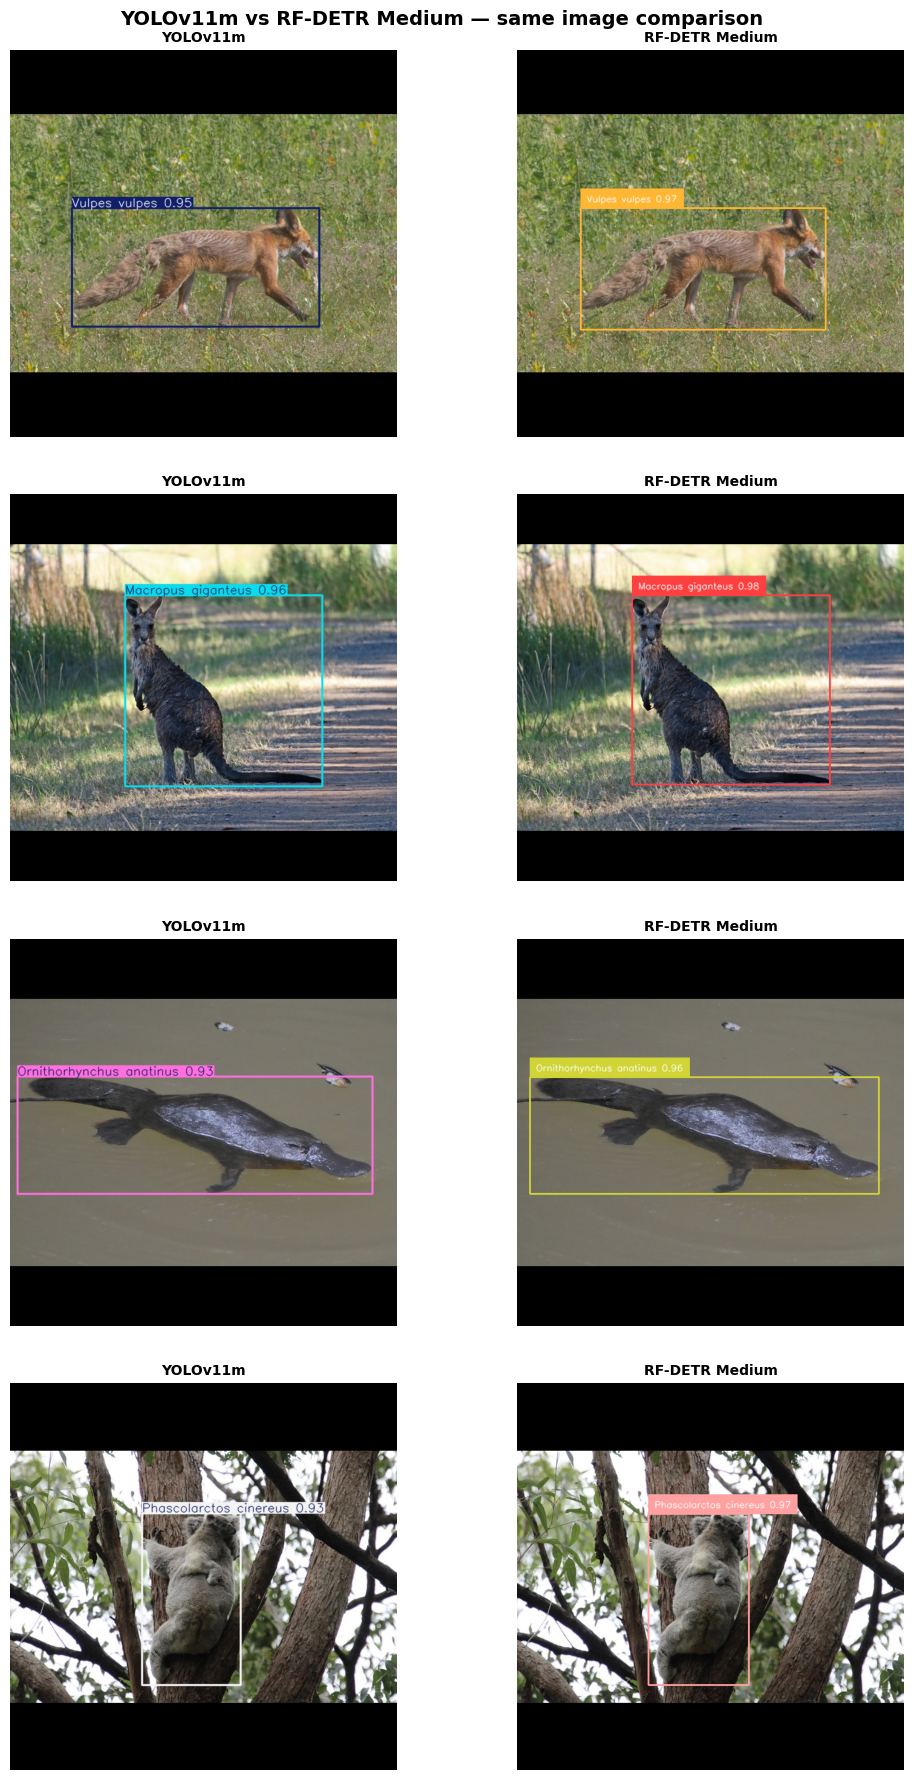

Saved: comparison_4images.png


In [29]:
test_imgs = random.sample(list(Path(TEST_IMAGES).glob('*.*')), 4)

yolo_results   = best_yolo.predict(test_imgs, conf=CONF_THRESH, device=device)
rfdetr_results = [best_rfdetr.predict(Image.open(p), threshold=CONF_THRESH) for p in test_imgs]

class_names = [
    'Dromaius novaehollandiae', 'Macropus giganteus', 'Phascolarctos cinereus',
    'Wallabia bicolor', 'Vulpes vulpes', 'Ornithorhynchus anatinus',
    'Vombatus ursinus', 'Dasyurus maculatus', 'Tachyglossus aculeatus', 'Casuarius casuarius'
]

fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle('YOLOv11m vs RF-DETR Medium — same image comparison',
             fontsize=14, fontweight='bold', y=0.99)

for i, img_path in enumerate(test_imgs):
    # YOLO left
    yolo_ann = yolo_results[i].plot(line_width=2)
    axes[i, 0].imshow(yolo_ann[..., ::-1])
    axes[i, 0].axis('off')
    axes[i, 0].set_title('YOLOv11m', fontsize=10, fontweight='bold')

    # RF-DETR right
    image  = Image.open(img_path)
    det    = rfdetr_results[i]
    labels = [f"{class_names[cid]} {conf:.2f}"
              for cid, conf in zip(det.class_id, det.confidence)]
    ann    = sv.BoxAnnotator().annotate(image.copy(), det)
    ann    = sv.LabelAnnotator().annotate(ann, det, labels=labels)
    axes[i, 1].imshow(ann)
    axes[i, 1].axis('off')
    axes[i, 1].set_title('RF-DETR Medium', fontsize=10, fontweight='bold')

plt.subplots_adjust(top=0.97, hspace=0.15)
plt.savefig('comparison_4images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_4images.png")

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

species = ['Emu', 'Kangaroo', 'Koala', 'Wallaby', 'Fox', 
           'Platypus', 'Wombat', 'Quoll', 'Echidna', 'Cassowary']

yolo_map   = [0.851, 0.943, 0.884, 0.825, 0.901, 0.837, 0.936, 0.891, 0.784, 0.877]
yolo_prec  = [0.888, 0.971, 0.985, 0.993, 0.967, 0.968, 0.923, 0.938, 1.000, 0.937]
yolo_rec   = [0.817, 0.932, 0.873, 0.798, 0.909, 0.776, 0.903, 0.859, 0.765, 0.850]

rfdetr_ap  = [0.873, 0.897, 0.767, 0.791, 0.801, 0.600, 0.908, 0.673, 0.691, 0.688]
rfdetr_prec= [0.944, 0.958, 0.920, 1.000, 0.986, 0.904, 0.971, 0.866, 1.000, 1.000]
rfdetr_rec = [0.893, 0.944, 0.831, 0.789, 0.896, 0.753, 0.919, 0.753, 0.761, 0.745]

yolo_f1   = [round(2*p*r/(p+r), 3) for p, r in zip(yolo_prec,   yolo_rec)]
rfdetr_f1 = [round(2*p*r/(p+r), 3) for p, r in zip(rfdetr_prec, rfdetr_rec)]

df = pd.DataFrame({
    'Species'         : species,
    'YOLO mAP@50'     : yolo_map,
    'YOLO Precision'  : yolo_prec,
    'YOLO Recall'     : yolo_rec,
    'YOLO F1'         : yolo_f1,
    'RFDETR AP 50:95' : rfdetr_ap,
    'RFDETR Precision': rfdetr_prec,
    'RFDETR Recall'   : rfdetr_rec,
    'RFDETR F1'       : rfdetr_f1,
})

print(df.to_string(index=False))

  Species  YOLO mAP@50  YOLO Precision  YOLO Recall  YOLO F1  RFDETR AP 50:95  RFDETR Precision  RFDETR Recall  RFDETR F1
      Emu        0.851           0.888        0.817    0.851            0.873             0.944          0.893      0.918
 Kangaroo        0.943           0.971        0.932    0.951            0.897             0.958          0.944      0.951
    Koala        0.884           0.985        0.873    0.926            0.767             0.920          0.831      0.873
  Wallaby        0.825           0.993        0.798    0.885            0.791             1.000          0.789      0.882
      Fox        0.901           0.967        0.909    0.937            0.801             0.986          0.896      0.939
 Platypus        0.837           0.968        0.776    0.861            0.600             0.904          0.753      0.822
   Wombat        0.936           0.923        0.903    0.913            0.908             0.971          0.919      0.944
    Quoll        0.891  